In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from pandasql import sqldf

In [38]:
# Load the datasets into df's

# Fact
fact = pd.read_csv('curated_data/football_data_fact.csv')

# Player
player = pd.read_csv('curated_data/player_data_dim.csv')
player_keeper = pd.read_csv('curated_data/player_keeper_data_subdim.csv')
player_defence = pd.read_csv('curated_data/player_defence_data_subdim.csv')
player_value = pd.read_csv('curated_data/player_max_value_data_subdim.csv')
player_misc = pd.read_csv('curated_data/player_misc_data_subdim.csv')
player_overall = pd.read_csv('curated_data/player_overall_stats_data_subdim.csv')
player_passing = pd.read_csv('curated_data/player_passing_data_subdim.csv')
player_shooting = pd.read_csv('curated_data/player_shooting_data_subdim.csv')

# Selecting required fields from each table and building position based df's to use in ML model

#Filtering the dfs by position for faster querying times
player = player[player['position'] == 'GK']
player_keeper = player_keeper[player_keeper['position'] == 'GK']
player_overall = player_overall[player_overall['position'] == 'GK']
fact = fact[fact['position'] =='GK']

keeper_query = """
                SELECT a.player_id, 
                       a.comp_id,
                       CASE WHEN a.position='GK' THEN 1
                            WHEN a.position='DF' THEN 2
                            WHEN a.position='DF,MF' THEN 3
                            WHEN a.position='MF' THEN 4
                            WHEN a.position='MF,FW' THEN 5
                            WHEN a.position='FW' THEN 6
                       END as position,
                       b.season,
                       b.goals_against_per_90,
                       b.shots_on_target_against,
                       b.saves,
                       b.clean_sheets,
                       b.penalty_kicks_saved,
                       b.starts,
                       b.matches_played,
                       b.yellow_cards,
                       b.red_cards,
                       b.max_market_value

                FROM fact a
                LEFT JOIN
                            (SELECT a.player_id,
                                    a.player,
                                    a.position,
                                    a.age,
                                    a.club,
                                    a.league,
                                    SUBSTR(a.season,1,4) as season,
                                    b.goals_against/90 as goals_against_per_90,
                                    b.shots_on_target_against,
                                    b.saves,
                                    b.clean_sheets,
                                    b.penalty_kicks_saved,
                                    c.starts,
                                    c.matches_played,
                                    c.yellow_cards,
                                    c.red_cards,
                                    f.max_market_value

                            FROM player a
                            LEFT JOIN player_keeper b
                                ON a.player_id=b.player_id and a.season=b.season and a.league=b.league and a.club=b.club
                            LEFT JOIN player_overall c
                                ON a.player_id=c.player_id and a.season=c.season and a.league=c.league and a.club = c.club
                            LEFT JOIN player_value f
                                ON a.player=f.player and a.season=f.season and a.league=f.league ) b

                        ON  a.player_id=b.player_id
                    GROUP BY 1,2

                """
keeper_df = sqldf(keeper_query, locals())

for col in keeper_df.columns:

    keeper_df[col] = keeper_df[col].fillna('-1')
    if 'per_90' in col:
        keeper_df[col] = round(keeper_df[col].astype(float),4)
    else:
        keeper_df[col] = keeper_df[col].astype(int)



keeper_df.to_csv('keep_test.csv')

# player = player[player['position'] == 'GK']
# player_keeper = player_keeper[player_keeper['position'] == 'GK']
# player_overall = player_overall[player_overall['position'] == 'GK']
# player_defence = player_defence[player_defence['position'] == 'GK']
# player_misc = player_misc[player_misc['position'] == 'GK']
# player_passing = player_passing[player_passing['position'] == 'GK']
# player_shooting = player_shooting[player_shooting['position'] == 'GK']

# def_query = """
#                 SELECT  a.player_id,
#                         a.player,
#                         a.position,
#                         a.age,
#                         a.season,
#                         c.goals,
#                         c.assists,
#                         c.starts/c.matches_played as starts_per_matches_played,
#                         c.yellow_cards,
#                         c.red_cards,
#                         d.fouls_committed/d.90s_played as fouls_committed_per_90,
#                         d.crosses/d.90s_played as crosses_per_90,
#                         d.interceptions/d.90s_played as interceptions_per_90,
#                         d.tackles_won/d.90s_played as tackles_per_90,
#                         d.penalty_kicks_conceded,
#                         d.ball_recoveries/d.90s_played as ball_recoveries_per_90,
#                         d.%_of_ariels_won as pct_ariel_duals_won,
#                         f.max_market_value

#                 FROM player (where=('DF' in position)) a
#                 LEFT JOIN player_overall (where=('DF' in position)) c
#                     ON a.player_id=c.player_id and a.season=c.season and a.league=c.league
#                 LEFT JOIN player_misc (where=('DF' in position)) d
#                     ON a.player_id=d.player_id and a.season=d.season and a.league=d.league
#                 LEFT JOIN player_value f
#                     ON a.player=f.player and a.season=f.season and a.league=f.league
                    
#                 """

# def_df = sqldf(def_query, locals())


# player = player[player['position'] == 'GK']
# player_keeper = player_keeper[player_keeper['position'] == 'GK']
# player_overall = player_overall[player_overall['position'] == 'GK']
# player_defence = player_defence[player_defence['position'] == 'GK']
# player_misc = player_misc[player_misc['position'] == 'GK']
# player_passing = player_passing[player_passing['position'] == 'GK']
# player_shooting = player_shooting[player_shooting['position'] == 'GK']

# mid_query = """
#                 SELECT  a.player_id,
#                         a.player,
#                         a.position,
#                         a.age,
#                         a.season,
#                         c.goals,
#                         c.assists,
#                         c.goals/90 as goals_per_90,
#                         c.assists/90 as assists_per_90,
#                         c.yellow_cards,
#                         c.red_cards,
#                         c.npxg_+_xag/90 as npxg_+_xag_per_90,
#                         d.fouls_committed/d.90s_played as fouls_committed_per_90,
#                         d.fouls_drawn/d.90s_played as fouls_drawn_per_90,
#                         d.crosses/d.90s_played as crosses_per_90,
#                         d.interceptions/d.90s_played as interceptions_per_90,
#                         d.tackles_won/d.90s_played as tackles_per_90,
#                         d.penalty_kicks_won,
#                         d.penalty_kicks_conceded,
#                         d.ball_recoveries/d.90s_played as ball_recoveries_per_90,
#                         d.%_of_ariels_won as pct_ariel_duals_won,
#                         e.shots_on_target/90 as shots_on_target_per_90,
#                         e.goals/shot as goals_per_shot,
#                         f.max_market_value

#                 FROM player (where=('MF' in position)) a
#                 LEFT JOIN player_overall (where=('MF' in position)) c
#                     ON a.player_id=c.player_id and a.season=c.season and a.league=c.league
#                 LEFT JOIN player_misc (where=('MF' in position)) d
#                     ON a.player_id=d.player_id and a.season=d.season and a.league=d.league
#                 LEFT JOIN player_shooting (where=('MF' in position)) e
#                     ON a.player_id=e.player_id and a.season=e.season and a.league=e.league    
#                 LEFT JOIN player_value f
#                     ON a.player=f.player and a.season=f.season and a.league=f.league                                   
#                 """

# mid_df = sqldf(mid_query, locals())


# player = player[player['position'] == 'GK']
# player_keeper = player_keeper[player_keeper['position'] == 'GK']
# player_overall = player_overall[player_overall['position'] == 'GK']
# player_defence = player_defence[player_defence['position'] == 'GK']
# player_misc = player_misc[player_misc['position'] == 'GK']
# player_passing = player_passing[player_passing['position'] == 'GK']
# player_shooting = player_shooting[player_shooting['position'] == 'GK']


# attck_query = """
#                 SELECT  a.player_id,
#                         a.player,
#                         a.position,
#                         a.age,
#                         a.season,
#                         c.goals,
#                         c.assists,
#                         c.goals/90 as goals_per_90,
#                         c.assists/90 as assists_per_90,
#                         c.yellow_cards,
#                         c.red_cards,
#                         c.npxg_+_xag/90 as npxg_+_xag_per_90,
#                         d.fouls_drawn/d.90s_played as fouls_drawn_per_90,
#                         d.crosses/d.90s_played as crosses_per_90,
#                         d.penalty_kicks_won,
#                         d.%_of_ariels_won as pct_ariel_duals_won,
#                         e.shots_on_target/90 as shots_on_target_per_90,
#                         e.goals/shot as goals_per_shot,
#                         f.max_market_value

#                 FROM player (where=('MF' in position)) a
#                 LEFT JOIN player_overall (where=('MF' in position)) c
#                     ON a.player_id=c.player_id and a.season=c.season and a.league=c.league
#                 LEFT JOIN player_misc (where=('MF' in position)) d
#                     ON a.player_id=d.player_id and a.season=d.season and a.league=d.league
#                 LEFT JOIN player_shooting (where=('MF' in position)) e
#                     ON a.player_id=e.player_id and a.season=e.season and a.league=e.league
#                 LEFT JOIN player_value f
#                     ON a.player=f.player and a.season=f.season and a.league=f.league                 
#                 """

# attck_df = sqldf(attck_query, locals())

print(keeper_df.head())
# print(def_df.head())
# print(mid_df.head())
# print(attck_df.head())




   player_id  comp_id  position  season  goals_against_per_90  \
0          9       13         1    2021                0.4333   
1          9       15         1    2021                0.4333   
2          9       35         1    2021                0.4333   
3          9       47         1    2021                0.4333   
4         16        4         1    2021                0.0667   

   shots_on_target_against  saves  clean_sheets  penalty_kicks_saved  starts  \
0                      128     90            12                    0      34   
1                      128     90            12                    0      34   
2                      128     90            12                    0      34   
3                      128     90            12                    0      34   
4                       16     10             1                    0       3   

   matches_played  yellow_cards  red_cards  max_market_value  
0              34             1          0                -1  
1 

   player_id  comp_id  position  season  goals_against_per_90  \
0          9       13         1    2021                0.4333   
1          9       15         1    2021                0.4333   
2          9       35         1    2021                0.4333   
3          9       47         1    2021                0.4333   
4         16        4         1    2021                0.0667   

   shots_on_target_against  saves  clean_sheets  penalty_kicks_saved  starts  \
0                      128     90            12                    0      34   
1                      128     90            12                    0      34   
2                      128     90            12                    0      34   
3                      128     90            12                    0      34   
4                       16     10             1                    0       3   

   matches_played  yellow_cards  red_cards  max_market_value  saves_per_match  \
0              34             1          0     

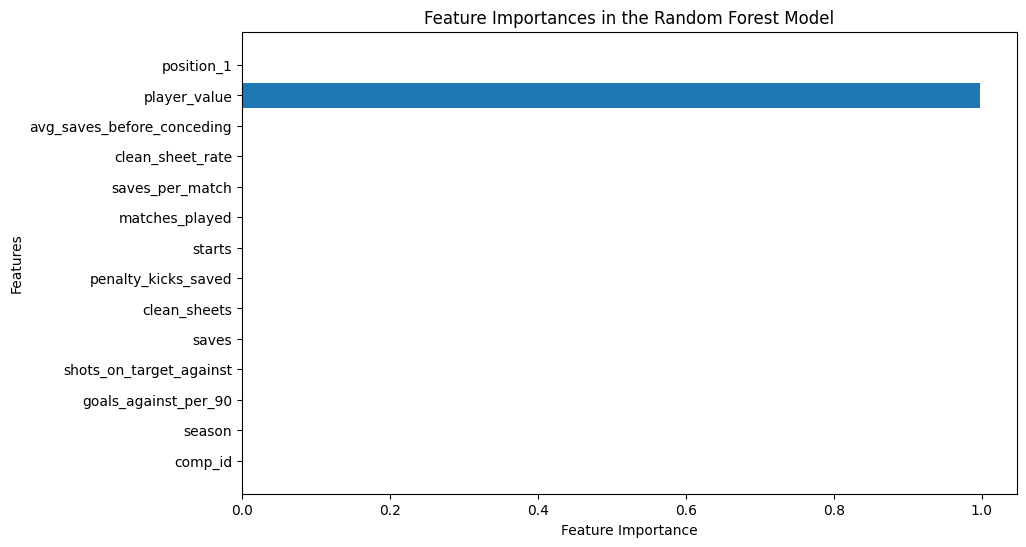

ValueError: Found array with 0 sample(s) (shape=(0, 14)) while a minimum of 1 is required by StandardScaler.

In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Replace inf and -inf values with NaN, then fill NaN with -1
keeper_df.replace([np.inf, -np.inf], np.nan, inplace=True)
keeper_df.fillna(-1, inplace=True)

# Feature Engineering
keeper_df['saves_per_match'] = keeper_df['saves'] / keeper_df['matches_played']
keeper_df['clean_sheet_rate'] = keeper_df['clean_sheets'] / keeper_df['matches_played']
keeper_df['avg_saves_before_conceding'] = keeper_df['saves_per_match'] / keeper_df['goals_against_per_90']

# Ensure no division by zero or infinity
keeper_df.replace([np.inf, -np.inf], np.nan, inplace=True)
keeper_df.fillna(-1, inplace=True)

# Separate rows with valid market values
valid_data = keeper_df[keeper_df['max_market_value'] != -1]
print(valid_data.head())

# Select relevant features and target variable for training
X_valid = valid_data.drop(['max_market_value', 'player_id', 'yellow_cards','red_cards'], axis=1)
y_valid = valid_data['max_market_value']

# Encode categorical data
X_valid = pd.get_dummies(X_valid, columns=['position'])

# Feature Scaling
scaler = StandardScaler()
X_valid_scaled = scaler.fit_transform(X_valid)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_valid_scaled, y_valid, test_size=0.2, random_state=42)

# Create a Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the regressor
rf_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared Score: {r2:.2f}')

# Cross-validation to ensure model robustness
scores = cross_val_score(rf_regressor, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
mse_scores = -scores
print(f'Cross-validated MSE: {mse_scores.mean():.2f}')

# Feature Importance
feature_importances = rf_regressor.feature_importances_
features = X_valid.columns

plt.figure(figsize=(10, 6))
plt.barh(features, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importances in the Random Forest Model')
plt.show()

# Predict the missing max_market_values
missing_data = keeper_df[keeper_df['max_market_value'] == -1]
X_missing = missing_data.drop(['max_market_value', 'player_id', 'yellow_cards'], axis=1)

# Ensure the feature set matches exactly
X_missing = pd.get_dummies(X_missing, columns=['position'])
X_missing = X_missing.reindex(columns=X_valid.columns, fill_value=0)
X_missing_scaled = scaler.transform(X_missing)

predicted_values = rf_regressor.predict(X_missing_scaled)

# Fill in the missing values
keeper_df.loc[keeper_df['max_market_value'] == -1, 'max_market_value'] = predicted_values

# Output a new column named player_value
keeper_df['player_value'] = keeper_df['max_market_value']

keeper_df.to_csv('keeper_value.csv')


In [ ]:
# Club
# club = pd.read_csv('curated_data/club_data_dim.csv')
# club_keeper = pd.read_csv('curated_data/club_keeper_data_subdim.csv')
# club_defence = pd.read_csv('curated_data/club_defence_data_subdim.csv')
# club_placing = pd.read_csv('curated_data/club_placing_data_subdim.csv')
# club_misc = pd.read_csv('curated_data/club_misc_data_subdim.csv')
# club_overall = pd.read_csv('curated_data/club_overall_stats_data_subdim.csv')
# club_passing = pd.read_csv('curated_data/club_passing_data_subdim.csv')
# club_shooting = pd.read_csv('curated_data/club_shooting_data_subdim.csv')
# club_rank = pd.read_csv('curated_data/club_uefa_rank_data_subdim.csv')

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load data
fact_data = pd.read_csv('fact_table.csv')
dim_player = pd.read_csv('dim_player.csv')
dim_club = pd.read_csv('dim_club.csv')

# Function to process each season's data
def process_season(season):
    # Filter data for the season
    season_data = fact_data[fact_data['season'] == season]

    # Merge with dimension tables
    season_data = pd.merge(season_data, dim_player, on='player_id', how='left')
    season_data = pd.merge(season_data, dim_club, on='club_id', how='left')
    
    # Handle missing values
    season_data.fillna(-1, inplace=True)
    
    # Feature engineering
    season_data['goals_per_90'] = season_data['goals'] / season_data['90s_played']
    season_data['assists_per_90'] = season_data['assists'] / season_data['90s_played']
    
    # Encode categorical data
    season_data = pd.get_dummies(season_data, columns=['nation', 'position', 'league'])
    
    # Define features and target
    features = [col for col in season_data.columns if col not in ['player_id', 'player', 'max_market_value']]
    X = season_data[features]
    y = season_data['max_market_value']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Predict and evaluate
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    print(f'Season: {season}, Mean Squared Error: {mse}')
    
    # Visualize
    plt.scatter(y_test, predictions)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title(f'Season: {season}')
    plt.show()

# List of seasons to process
seasons = fact_data['season'].unique()

# Process each season
for season in seasons:
    process_season(season)
